<a href="https://colab.research.google.com/github/prasanna-venkatesh-m/Analytics-Forecast/blob/main/Train_Overall_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

In [2]:
def load_data(file_path):
    df = pd.read_csv(file_path)

    data_df = df.copy()

    data_df['Date'] = pd.to_datetime(
        data_df['Date'],
        dayfirst=True
    )

    data_df = data_df.sort_values(
        ['BranchID', 'Date']
    )

    return data_df

In [3]:
TARGET_COLUMNS = [
    'CountofGroup',
    'CountofClientName',
    'CountofAccountID',
    'CountofCreditOfficerID',
    'SumofPrincipalOutstanding',
    'SumofInterestOutstanding',
    'SumofTotalPrincipalOverdue',
    'SumofTotalInterestOverdue',
    'SumofTotalPAR'
]

FEATURES = [
    'lag_1',
    'lag_2',
    'ema_7',
    'lag_3',
    'diff_1'
]


def create_time_series_features(
    data_df,
    target_columns,
    group_col='BranchID'
):
    data_df['day'] = data_df['Date'].dt.day

    data_df['month'] = data_df['Date'].dt.month

    data_df['year'] = data_df['Date'].dt.year

    data_df['dayofweek'] = (
        data_df['Date'].dt.dayofweek
    )

    for col in target_columns:
        for lag in [1, 2, 3]:
            data_df[f'{col}_lag_{lag}'] = (
                data_df
                .groupby(group_col)[col]
                .shift(lag)
            )

        data_df[f'{col}_ema_7'] = (
            data_df
            .groupby(group_col)[col]
            .transform(
                lambda x: x.shift(1).ewm(span=7).mean()
            )
        )

        data_df[f'{col}_diff_1'] = (
            data_df
            .groupby(group_col)[col]
            .diff(1)
        )

    return data_df

In [4]:
def split_data(data_df, split_date):
    overall_train_df = data_df[
        data_df['Date'] < split_date
    ]

    overall_test_df = data_df[
        data_df['Date'] >= split_date
    ]

    return (
        overall_train_df,
        overall_test_df
    )

In [5]:
TRAIN_END_DATE = '2026-04-01'

df = load_data('/content/dat.csv')
data_df = create_time_series_features(
    df,
    TARGET_COLUMNS
)

# --Train/Test Split--
(
  overall_train_df,
  overall_test_df
) = split_data(
  data_df,
  TRAIN_END_DATE
)

In [6]:
def get_feature_list(TARGET_COLUMN):
  return [
      'day',
      'month',
      'year',
      'dayofweek',
      'BranchID',
      f'{TARGET_COLUMN}_lag_1',
      f'{TARGET_COLUMN}_lag_2',
      f'{TARGET_COLUMN}_lag_3',
      f'{TARGET_COLUMN}_ema_7',
      f'{TARGET_COLUMN}_diff_1'
  ]

In [7]:
X_train = overall_train_df[get_feature_list('SumofTotalPrincipalOverdue')]
y_train = overall_train_df['SumofTotalPrincipalOverdue']

X_test = overall_test_df[get_feature_list('SumofTotalPrincipalOverdue')]
y_test = overall_test_df['SumofTotalPrincipalOverdue']

In [8]:
X_train

,day,month,year,dayofweek,BranchID,SumofTotalPrincipalOverdue_lag_1,SumofTotalPrincipalOverdue_lag_2,SumofTotalPrincipalOverdue_lag_3,SumofTotalPrincipalOverdue_ema_7,SumofTotalPrincipalOverdue_diff_1
0,31,3,2023,4,1,NaN,NaN,NaN,NaN,NaN
152,1,4,2023,5,1,2836866.0,NaN,NaN,2836866.0,0.0
304,2,4,2023,6,1,2836866.0,2836866.0,NaN,2836866.0,0.0
456,3,4,2023,0,1,2836866.0,2836866.0,2836866.0,2836866.0,0.0
608,4,4,2023,1,1,2836866.0,2836866.0,2836866.0,2836866.0,0.0
...,...,...,...,...,...,...,...,...,...,...
166135,27,3,2026,4,153,0.0,0.0,0.0,0.0,0.0
166287,28,3,2026,5,153,0.0,0.0,0.0,0.0,0.0
166439,29,3,2026,6,153,0.0,0.0,0.0,0.0,0.0
166591,30,3,2026,0,153,0.0,0.0,0.0,0.0,0.0


In [9]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=6,
    objective='reg:squarederror'
)

model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [10]:
preds = model.predict(X_test)

In [11]:
results_df = overall_test_df[
    ['Date', 'BranchID']
].copy()

results_df['Actual'] = y_test.values

results_df['Predicted'] = preds

In [12]:
results_df

,Date,BranchID,Actual,Predicted
166744,2026-04-01,1,7247838,7.241498e+06
166896,2026-04-02,1,7257621,7.236344e+06
167048,2026-04-03,1,7258864,7.230300e+06
167200,2026-04-04,1,7274759,7.242660e+06
167352,2026-04-05,1,7274759,7.226897e+06
...,...,...,...,...
172367,2026-05-07,153,403,2.336254e+04
172519,2026-05-08,153,403,2.336254e+04
172671,2026-05-09,153,403,2.336254e+04
172823,2026-05-10,153,403,2.336254e+04


In [13]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

mae = mean_absolute_error(
    y_test,
    preds
)

mse = mean_squared_error(
    y_test,
    preds
)

rmse = np.sqrt(mse)

mape = np.mean(
    np.abs(
        (y_test - preds)
        / np.where(y_test == 0, 1, y_test)
    )
) * 100

smape = np.mean(
    2 * np.abs(preds - y_test)
    / (
        np.abs(y_test)
        + np.abs(preds)
        + 1e-10
    )
) * 100

In [14]:
print("========== METRICS ==========")

print(f"MAE  : {mae:,.2f}")

print(f"MSE  : {mse:,.2f}")

print(f"RMSE : {rmse:,.2f}")

print(f"MAPE : {mape:.2f}%")

print(f"SMAPE: {smape:.2f}%")

========== METRICS ==========
MAE  : 70,919.44
MSE  : 72,979,152,896.00
RMSE : 270,146.54
MAPE : 15040.12%
SMAPE: 3.20%


In [15]:
branch_id = 1

branch_df = results_df[
    results_df['BranchID'] == branch_id
].sort_values('Date')

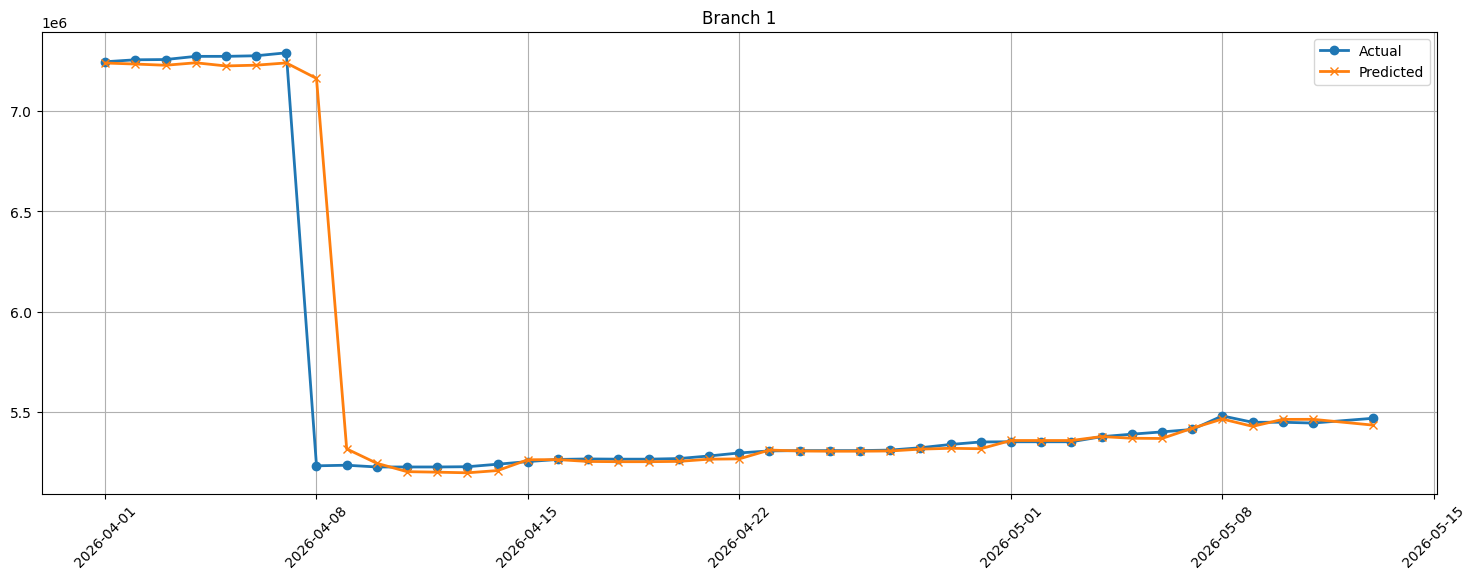

In [16]:
plt.figure(figsize=(18,6))

plt.plot(
    branch_df['Date'],
    branch_df['Actual'],
    label='Actual',
    linewidth=2,
    marker='o'
)

plt.plot(
    branch_df['Date'],
    branch_df['Predicted'],
    label='Predicted',
    linewidth=2,
    marker='x'
)

plt.title(
    f'Branch {branch_id}'
)

plt.legend()

plt.grid()

plt.xticks(rotation=45)

plt.show()

In [17]:
branch_df

,Date,BranchID,Actual,Predicted
166744,2026-04-01,1,7247838,7241497.5
166896,2026-04-02,1,7257621,7236344.0
167048,2026-04-03,1,7258864,7230300.0
167200,2026-04-04,1,7274759,7242659.5
167352,2026-04-05,1,7274759,7226897.0
167504,2026-04-06,1,7277729,7230732.5
167656,2026-04-07,1,7292484,7241942.5
167808,2026-04-08,1,5229689,7164625.0
167960,2026-04-09,1,5232726,5314224.0
168112,2026-04-10,1,5223949,5242221.5


In [18]:
def forecast_next_30_days(
    model,
    data_df,
    branch_id,
    target_col,
    features
):
    forecast = []

    branch_df = data_df[
        data_df['BranchID'] == branch_id
    ].sort_values('Date').copy()

    last_date = branch_df['Date'].max()

    history = branch_df[target_col].tolist()

    for i in range(1, 31):

        future_date = last_date + pd.Timedelta(days=i)

        # --------------------------
        # Build feature row
        # --------------------------
        new_row = {}

        new_row['BranchID'] = branch_id

        new_row['day'] = future_date.day
        new_row['month'] = future_date.month
        new_row['year'] = future_date.year
        new_row['dayofweek'] = future_date.dayofweek

        # --------------------------
        # LAG FEATURES
        # --------------------------
        new_row[f'{target_col}_lag_1'] = history[-1]
        new_row[f'{target_col}_lag_2'] = history[-2]
        new_row[f'{target_col}_lag_3'] = history[-3]

        # EMA (simple approx)
        series = pd.Series(history)
        new_row[f'{target_col}_ema_7'] = series.ewm(span=7).mean().iloc[-1]

        # DIFF
        new_row[f'{target_col}_diff_1'] = history[-1] - history[-2]

        # --------------------------
        # Predict
        # --------------------------
        X_input = pd.DataFrame([new_row])[features]

        pred = model.predict(X_input)[0]

        # store result
        forecast.append({
            'Date': future_date,
            'BranchID': branch_id,
            'Predicted': pred
        })

        # IMPORTANT: append prediction to history
        history.append(pred)

    return pd.DataFrame(forecast)

In [22]:
forecast_df = forecast_next_30_days(
    model=model,
    data_df=data_df,
    branch_id=1,
    target_col='SumofTotalPrincipalOverdue',
    features=get_feature_list('SumofTotalPrincipalOverdue')
)

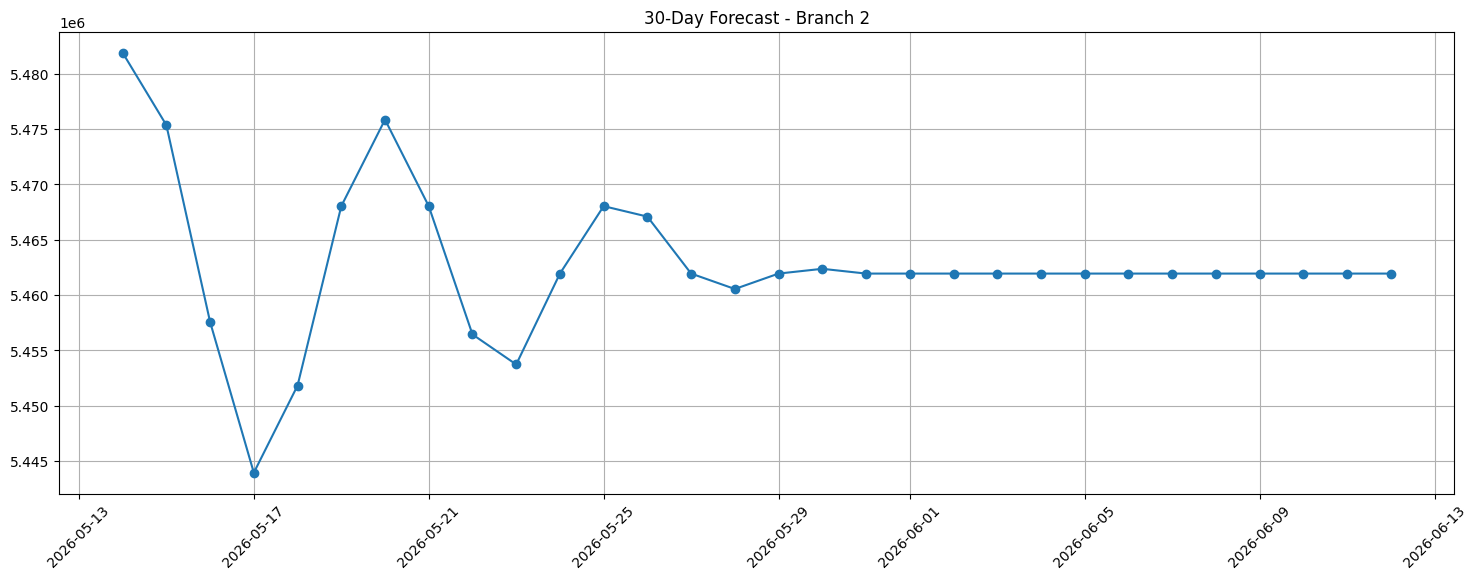

In [23]:
plt.figure(figsize=(18,6))

plt.plot(
    forecast_df['Date'],
    forecast_df['Predicted'],
    marker='o'
)

plt.title("30-Day Forecast - Branch 2")

plt.grid()

plt.xticks(rotation=45)

plt.show()

In [24]:
forecast_df

,Date,BranchID,Predicted
0,2026-05-14,1,5481899.5
1,2026-05-15,1,5475356.5
2,2026-05-16,1,5457573.0
3,2026-05-17,1,5443946.5
4,2026-05-18,1,5451820.5
5,2026-05-19,1,5468035.5
6,2026-05-20,1,5475854.0
7,2026-05-21,1,5468035.5
8,2026-05-22,1,5456444.0
9,2026-05-23,1,5453728.0
